# Level 3b Advanced ViT_B_16

**Task**: Binary classification - Cascade Level 3a Advanced Stages (III and IV)
**Model**: ViT_B_16
**Platform**: Kaggle (GPU T$)
**Hyperparameters**: Pre-filled from Optuna search

---

> **Architecture note - `WrappedModel`**
> Unlike the Early stage notebooks which attach the head directly onto the backbone. Here the backbone's native classifier is replace with `nn.Identity`
> and a separate `WrappedModel(backbone, head)` wrapper routes raw feature vectors to the custom head.
> This is necessary for **CosFace/ArcFace** which need normalised embeddings,
> and also used for 'linear' / 'mlp' / 'multi_stage_head' for consistency. All heads output `[B, 2]` logits - > `CrossEntropyLoss` -> `argmax` for predictions.
> **CosFace / ArcFace - binary scale/margin** - For a 2-class problem
> the angular margin must be more conservative than for many classes. Both heads auto-reduce `scale` to `15.0` and `margin` to `0.3` when `num_classes == 2`. Override via `SCALE` / `MARGIN` in Section 2.

> **Augumentation**
> Stage III vs IV presents more subtle tissue-depth cues than early stages, so the training pipeline uses a stronger policy: `A.Affine`, `A.GaussianBlur`, `A.GaussNoise` and a colour-jitter `OneOf` block in addition to the base flips/crops.

## Notebook Structure

1. Environment setup.
2. Configuration - all hyperparameters in one place.
3. Dataset & stratified split (70 / 20 / 10).
4. Class distribution analysis.
5. Heads, WrappedModel, model builder, optimizers, schedulers, freeze helpers & early stopping.
6. Training loop.
7. Training curve analysis.
8. Evaluation - confusion matrix (raw + normalised).
9. Evaluation - full classification report.
10. Evaluation - ROC curve & AUC with Youden threshold.
11. Evaluation - threshold sensitivity analysis.
12. Model export & summary.

## 1. Environment Setup

In [1]:
!pip install -q accelerate albumentations timm adamp lion-pytorch

  Preparing metadata (setup.py) ... done


In [2]:
import os, gc, random, torch, timm
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import albumentations as A
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import models
from albumentations.pytorch import ToTensorV2
from accelerate import Accelerator
from adamp import AdamP
from lion_pytorch import Lion
from PIL import Image
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score,
)

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.benchmark     = False
torch.backends.cudnn.deterministic = True
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
print("Environment ready.")
print(f"PyTorch {torch.__version__} | timm {timm.__version__} | CUDA: {torch.cuda.is_available()}")

Environment ready.
PyTorch 2.9.0+cu126 | timm 1.0.24 | CUDA: True


/usr/local/lib/python3.12/dist-packages/torch/backends/__init__.py:46: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  self.setter(val)


## 2. Configuration

In [3]:
# Paths 
ROOT_DIR = "/kaggle/input/datasets/cezarytubacki/psd-advanced-stages/PSD - advanced"
OUTPUT_DIR = "/kaggle/working"

# Split 
TRAIN_RATIO = 0.70
VAL_RATIO = 0.20
TEST_RATIO = 0.10

#  Model 
MODEL_NAME = "ViT_B_16"

#  Head 
HEAD_TYPE = "mlp"

# Hyperparameters
DROPOUT = 0.5444905836413285
LR = 0.0011288971465078128
WEIGHT_DECAY = 1.9009441081922093e-05
BATCH_SIZE = 32
GRADIENT_ACCUMULATION = 2
NUM_EPOCHS = 50
LABEL_SMOOTHING = 0.0
OPTIMIZER_NAME = "AdamW"
SCHEDULER_NAME = "ReduceLROnPlateau"
UNFREEZE_EPOCH_STAGE1 = 1
UNFREEZE_EPOCH_STAGE2 = 6
NUM_BLOCKS_TO_UNFREEZE = 2

# Early stopping
ES_PATIENCE = 10
ES_DELTA = 1e-4

#  Scheduler params
_SCHED_MAP = {
    "CosineAnnealingLR" : {"T_max": NUM_EPOCHS},
    "ReduceLROnPlateau" : {"factor": 0.2442186569909322, "patience": 3, "min_lr": 1.444086507922539e-06},
    "StepLR" : {"step_size": 10, "gamma": 0.3},
    "ExponentialLR" : {"gamma": 0.95},
}
SCHEDULER_PARAMS = _SCHED_MAP[SCHEDULER_NAME]

# Margin-head parameters
SCALE = 30.0
MARGIN = 0.5
FORCE_SCALE = False  
FORCE_MARGIN = False
# Derived constants 
NUM_CLASSES = 2  # always 2 — Stage III vs Stage IV
IS_MARGIN_HEAD = HEAD_TYPE in ("cosface_head", "arcface_head")

print(f"Model : {MODEL_NAME}")
print(f"Head : {HEAD_TYPE}  (margin={IS_MARGIN_HEAD})")
print(f"Loss : CrossEntropyLoss  label_smoothing={LABEL_SMOOTHING}")
print(f"Optimizer : {OPTIMIZER_NAME} | LR: {LR:.2e} | WD: {WEIGHT_DECAY:.2e}")
print(f"Batch : {BATCH_SIZE} | Grad accum: {GRADIENT_ACCUMULATION} | Max epochs: {NUM_EPOCHS}")
print(f"Scheduler : {SCHEDULER_NAME} | {SCHEDULER_PARAMS}")
print(f"Early stop : patience={ES_PATIENCE}, delta={ES_DELTA}")
print(f"Unfreeze : stage1 @ ep {UNFREEZE_EPOCH_STAGE1} ({NUM_BLOCKS_TO_UNFREEZE} blocks),",
      f"stage2 @ ep {UNFREEZE_EPOCH_STAGE2} (full)")

Model : ViT_B_16
Head : mlp  (margin=False)
Loss : CrossEntropyLoss  label_smoothing=0.0
Optimizer : AdamW | LR: 1.13e-03 | WD: 1.90e-05
Batch : 32 | Grad accum: 2 | Max epochs: 50
Scheduler : ReduceLROnPlateau | {'factor': 0.2442186569909322, 'patience': 3, 'min_lr': 1.444086507922539e-06}
Early stop : patience=10, delta=0.0001
Unfreeze : stage1 @ ep 1 (2 blocks), stage2 @ ep 6 (full)


## 3. Dataset Classes & Stratified Split

In [4]:
class PressureSoreDataset(Dataset):
    """Loads images from class subfolders. Returns raw PIL Images."""
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.image_paths = []
        self.labels = []
        self.class_to_idx = {}
        self.idx_to_class = []

        for i, name in enumerate(sorted(os.listdir(root_dir))):
            if os.path.isdir(os.path.join(root_dir, name)):
                self.class_to_idx[name] = i
                self.idx_to_class.append(name)

        for name in sorted(os.listdir(root_dir)):
            label_dir = os.path.join(root_dir, name)
            if not os.path.isdir(label_dir):
                continue
            for fname in os.listdir(label_dir):
                fpath = os.path.join(label_dir, fname)
                if fpath.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
                    self.image_paths.append(fpath)
                    self.labels.append(self.class_to_idx[name])

        print(f"Found {len(self.image_paths)} images in {len(self.class_to_idx)} classes.")
        print(f"Class mapping: {self.class_to_idx}")

    def __len__(self):  return len(self.image_paths)
    def __getitem__(self, idx):
        return Image.open(self.image_paths[idx]).convert("RGB"), self.labels[idx]


class TransformedDataset(Dataset):
    """Wraps a Subset and applies an Albumentations transform."""
    def __init__(self, base_dataset, transform):
        self.base_dataset = base_dataset
        self.transform = transform

    def __len__(self):  return len(self.base_dataset)
    def __getitem__(self, idx):
        image, label = self.base_dataset[idx]
        if self.transform:
            if isinstance(self.transform, A.core.composition.BaseCompose):
                image = self.transform(image=np.array(image))["image"]
            else:
                image = self.transform(image)
        return image, label


# Load
full_dataset = PressureSoreDataset(ROOT_DIR)
all_labels = full_dataset.labels
class_names = full_dataset.idx_to_class
n_classes = len(class_names)

assert n_classes == 2, (
    f"Expected 2 classes (Stage III, Stage IV) but found {n_classes}: {class_names}.\n"
    "Check ROOT_DIR points to the correct Advanced subset."
)

# Stratified split
indices = list(range(len(full_dataset)))
train_idx, temp_idx = train_test_split(
    indices, test_size=(VAL_RATIO + TEST_RATIO),
    stratify=all_labels, random_state=SEED
)
temp_labels = [all_labels[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx, test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
    stratify=temp_labels, random_state=SEED
)

print(f"\nStratified split (seed={SEED}):")
for name, idx_list in [("Train", train_idx), ("Val", val_idx), ("Test", test_idx)]:
    split_lbl = [all_labels[i] for i in idx_list]
    counts = {c: split_lbl.count(v) for c, v in full_dataset.class_to_idx.items()}
    print(f"{name:5s}: {len(idx_list):4d} images | {counts}")

Found 620 images in 2 classes.
Class mapping: {'stage III': 0, 'stage IV': 1}

Stratified split (seed=42):
Train:  433 images | {'stage III': 216, 'stage IV': 217}
Val  :  124 images | {'stage III': 62, 'stage IV': 62}
Test :   63 images | {'stage III': 32, 'stage IV': 31}


## 4. Class Distribution Analysis

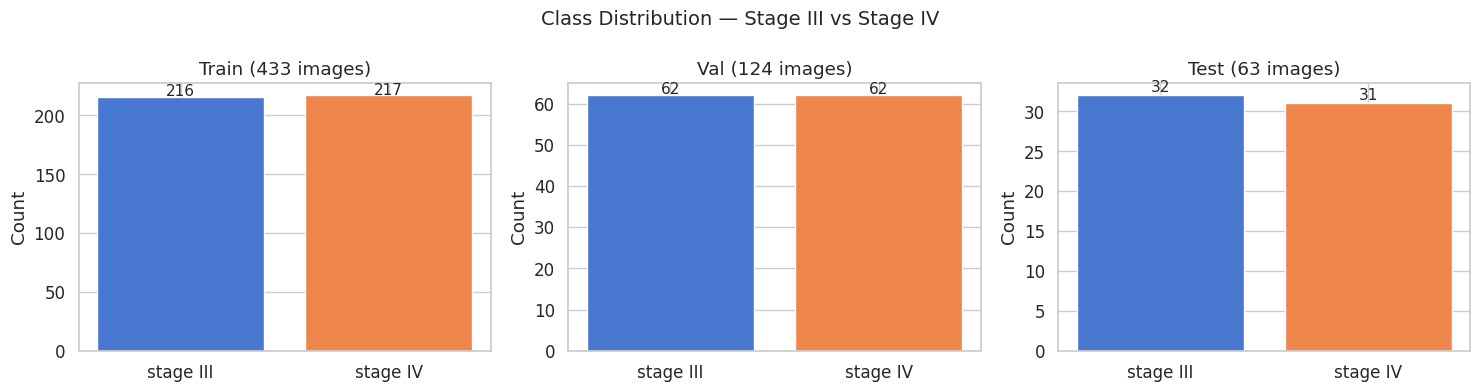

Train imbalance ratio: 1.00

Stage III vs IV is the hardest Advanced split in the cascade.
Stage III: full-thickness skin loss, subcutaneous fat visible.
Stage IV: full-thickness tissue loss, muscle/bone/tendon exposed.
Stronger augmentation + margin-based heads (CosFace/ArcFace) are recommended.


In [5]:
split_data = {
    "Train" : [all_labels[i] for i in train_idx],
    "Val" : [all_labels[i] for i in val_idx],
    "Test" : [all_labels[i] for i in test_idx],
}
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (split_name, lbls) in zip(axes, split_data.items()):
    counts = [lbls.count(v) for v in range(n_classes)]
    bars = ax.bar(class_names, counts, color=sns.color_palette("muted", n_classes))
    ax.set_title(f"{split_name} ({len(lbls)} images)")
    ax.set_ylabel("Count")
    for bar, v in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.5, str(v), ha="center", fontsize=11)
plt.suptitle("Class Distribution — Stage III vs Stage IV", fontsize=14)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

train_counts = [split_data["Train"].count(v) for v in range(n_classes)]
ratio = max(train_counts) / (min(train_counts) or 1)
flag  = "consider class weights or oversampling" if ratio > 2 else ""
print(f"Train imbalance ratio: {ratio:.2f}{flag}")
print()
print("Stage III vs IV is the hardest Advanced split in the cascade.")
print("Stage III: full-thickness skin loss, subcutaneous fat visible.")
print("Stage IV: full-thickness tissue loss, muscle/bone/tendon exposed.")
print("Stronger augmentation + margin-based heads (CosFace/ArcFace) are recommended.")

## 5. Heads, WrappedModel, Model Builder, Optimizer, Scheduler, Freeze Helpers & Early Stopping

In [6]:
# Classification Heads

class LinearHead(nn.Module):
    """Dropout → Linear. Receives pooled [B, C] features from WrappedModel."""
    def __init__(self, in_features, num_classes=2, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, num_classes),
        )

    def forward(self, x, labels=None):
        return self.net(x)


class MLPHead(nn.Module):
    """Dropout → FC → ReLU → Dropout → FC. Two-layer MLP."""
    def __init__(self, in_features, num_classes=2, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, in_features // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(in_features // 2, num_classes),
        )

    def forward(self, x, labels=None):
        return self.net(x)


class MultiStageHead(nn.Module):
    """Dropout → FC → BN → ReLU → FC. Compact bottleneck MLP."""
    def __init__(self, in_features, num_classes=2, dropout=0.5):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(in_features, in_features // 2)
        self.bn = nn.BatchNorm1d(in_features // 2)
        self.relu = nn.ReLU(inplace=True)
        self.fc2 = nn.Linear(in_features // 2, num_classes)

    def forward(self, x, labels=None):
        return self.fc2(self.relu(self.bn(self.fc1(self.dropout(x)))))


class CosFaceHead(nn.Module):
    """
    CosFace (additive cosine margin) classification head.
    Dropout is applied **inside** the head before normalisation.
    For num_classes == 2: scale auto-reduces to 15, margin to 0.3
    (overridden by FORCE_SCALE / FORCE_MARGIN in config).

    Training  → forward(x, labels)  subtracts margin from ground-truth cosine logit.
    Inference → forward(x)  returns raw scaled cosine logits.
    """
    def __init__(self, in_features, num_classes=2, scale=30.0, margin=0.35, dropout=0.0):
        super().__init__()
        # Conservative scale/margin for binary
        self.scale = scale  if (num_classes > 2 or FORCE_SCALE)  else 15.0
        self.margin = margin if (num_classes > 2 or FORCE_MARGIN) else 0.3
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, in_features))
        nn.init.xavier_uniform_(self.weight)
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x, labels=None):
        x = self.dropout(x)
        x = F.normalize(x, dim=1)
        w  = F.normalize(self.weight, dim=1)
        cosine = F.linear(x, w)                   # [B, num_classes]
        if labels is not None:
            one_hot = torch.zeros_like(cosine)
            one_hot.scatter_(1, labels.long().view(-1, 1), 1.0)
            cosine = cosine - one_hot * self.margin
        return cosine * self.scale


class ArcFaceHead(nn.Module):
    """
    ArcFace (additive angular margin) classification head.
    Dropout is applied **inside** the head before normalisation.
    For num_classes == 2: scale auto-reduces to 15, margin to 0.3
    (overridden by FORCE_SCALE / FORCE_MARGIN in config).

    Training  → forward(x, labels)  adds angular margin to ground-truth logit.
    Inference → forward(x) returns raw scaled cosine logits.
    """
    def __init__(self, in_features, num_classes=2, scale=30.0, margin=0.5, dropout=0.0):
        super().__init__()
        self.scale = scale if (num_classes > 2 or FORCE_SCALE)  else 15.0
        self.margin = margin if (num_classes > 2 or FORCE_MARGIN) else 0.3
        self.weight = nn.Parameter(torch.randn(num_classes, in_features))
        nn.init.xavier_uniform_(self.weight)
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x, labels=None):
        x = self.dropout(x)
        x = F.normalize(x, dim=1)
        w = F.normalize(self.weight, dim=1)
        logits = F.linear(x, w) # [B, num_classes]
        if labels is None:
            return logits * self.scale
        # Validate label range
        if labels.min() < 0 or labels.max() >= NUM_CLASSES:
            raise ValueError(
                f"Invalid labels {labels.min().item()}–{labels.max().item()}, "
                f"expected 0–{NUM_CLASSES-1}"
            )
        theta = torch.acos(torch.clamp(logits, -1.0 + 1e-7, 1.0 - 1e-7))
        target_logits = torch.cos(theta + self.margin)
        one_hot = torch.zeros_like(logits)
        one_hot.scatter_(1, labels.long().view(-1, 1), 1.0)
        logits = logits * (1 - one_hot) + target_logits * one_hot
        return logits * self.scale


print("All heads defined.")

All heads defined.


In [7]:
# WrappedModel

class WrappedModel(nn.Module):
    """
    Combines a backbone (with its classifier replaced by nn.Identity) and
    a custom head into a single nn.Module.

    Forward routing:
      - Training + margin head  : model(inputs, labels) → head receives labels for margin
      - Inference / val : model(inputs) → head returns raw scaled logits
      - Non-margin head : labels argument is always ignored
    """
    def __init__(self, backbone: nn.Module, head: nn.Module, num_classes: int):
        super().__init__()
        self.backbone = backbone
        self.head = head
        self.num_classes = num_classes

    def forward(self, x, labels=None):
        feats = self.backbone(x) # [B, in_features]
        if IS_MARGIN_HEAD:
            if self.training:
                if labels is None:
                    raise ValueError("Margin head requires labels during training.")
                return self.head(feats, labels.long())
            else:
                return self.head(feats, labels=None)
        else:
            return self.head(feats) # labels ignored


print("WrappedModel defined.")

WrappedModel defined.


In [8]:
# Model zoo


TIMM_MODELS = {
    "convnextv2_tiny" : "convnextv2_tiny.fcmae_ft_in22k_in1k",
    "convnextv2_base" : "convnextv2_base.fcmae_ft_in22k_in1k",
    "convnextv2_large" : "convnextv2_large.fcmae_ft_in22k_in1k",
    "vit_large_224" : "vit_large_patch32_224.orig_in21k",
    "deit3_large_224" : "deit3_large_patch16_224.fb_in22k_ft_in1k",
    "eva02_small_224" : "eva02_small_patch14_224.mim_in22k",
    "beit_large_224" : "beit_large_patch16_224",
    "coatnet_7" : "coatnet_rmlp_2_rw_384.sw_in12k_ft_in1k",
    "efficientnetv2_l" : "tf_efficientnetv2_l.in21k_ft_in1k",
    "nfnet_l0" : "eca_nfnet_l0",
}

# Block container for partial unfreeze (stage 1)
MODEL_LAYERS_MAP = {
    "convnextv2_tiny.fcmae_ft_in22k_in1k" : "stages",
    "convnextv2_base.fcmae_ft_in22k_in1k" : "stages",
    "convnextv2_large.fcmae_ft_in22k_in1k" : "stages",
    "vit_large_patch32_224.orig_in21k" : "blocks",
    "deit3_large_patch16_224.fb_in22k_ft_in1k" : "blocks",
    "eva02_small_patch14_224.mim_in22k" : "blocks",
    "beit_large_patch16_224" : "blocks",
    "coatnet_rmlp_2_rw_384.sw_in12k_ft_in1k" : "stages",
    "tf_efficientnetv2_l.in21k_ft_in1k" : "blocks",
    "eca_nfnet_l0" : "stages",
}


def build_model(
    model_name: str,
    num_classes: int = 2,
    dropout: float = 0.3,
    head_type: str = "arcface_head",
    scale: float = 30.0,
    margin: float = 0.5,
) -> WrappedModel:
    """
    Builds backbone + WrappedModel for Stage III vs IV.

    Steps:
      1. Load pretrained backbone (timm or torchvision).
      2. Strip backbone's native classifier → nn.Identity.
      3. Build chosen head (receives raw [B, in_features] features).
      4. Wrap in WrappedModel.

    All heads output [B, num_classes] → CrossEntropyLoss → argmax.
    """
    if isinstance(head_type, tuple):
        head_type = head_type[0]

    #  Torchvision zoo 
    TV_WEIGHTS = {
        "EfficientNet_B0" : models.EfficientNet_B0_Weights.IMAGENET1K_V1,
        "EfficientNet_B1" : models.EfficientNet_B1_Weights.IMAGENET1K_V2,
        "EfficientNet_B4" : models.EfficientNet_B4_Weights.IMAGENET1K_V1,
        "EfficientNet_B7" : models.EfficientNet_B7_Weights.IMAGENET1K_V1,
        "EfficientNet_V2_L" : models.EfficientNet_V2_L_Weights.IMAGENET1K_V1,
        "ViT_B_16" : models.ViT_B_16_Weights.IMAGENET1K_V1,
        "MaxVit_T" : models.MaxVit_T_Weights.IMAGENET1K_V1,
        "Wide_ResNet50_2": models.Wide_ResNet50_2_Weights.IMAGENET1K_V2,
        "ResNet50" : models.ResNet50_Weights.IMAGENET1K_V2,
        "ResNet152" : models.ResNet152_Weights.IMAGENET1K_V2,
        "Swin_V2_S" : models.Swin_V2_S_Weights.IMAGENET1K_V1,
        "Swin_V2_T" : models.Swin_V2_T_Weights.IMAGENET1K_V1,
        "ConvNeXt_Tiny" : models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1,
        "ConvNeXt_Base" : models.ConvNeXt_Base_Weights.IMAGENET1K_V1,
        "ConvNeXt_Large" : models.ConvNeXt_Large_Weights.IMAGENET1K_V1,
        "RegNet_Y_8GF" : models.RegNet_Y_8GF_Weights.IMAGENET1K_V2,
        "RegNet_Y_16GF" : models.RegNet_Y_16GF_Weights.IMAGENET1K_SWAG_E2E_V1,
    }
    TV_FN = {
        "EfficientNet_B0" : models.efficientnet_b0,
        "EfficientNet_B1" : models.efficientnet_b1,
        "EfficientNet_B4" : models.efficientnet_b4,
        "EfficientNet_B7" : models.efficientnet_b7,
        "EfficientNet_V2_L" : models.efficientnet_v2_l,
        "ViT_B_16" : models.vit_b_16,
        "MaxVit_T" : models.maxvit_t,
        "Wide_ResNet50_2" : models.wide_resnet50_2,
        "ResNet50" : models.resnet50,
        "ResNet152" : models.resnet152,
        "Swin_V2_S" : models.swin_v2_s,
        "Swin_V2_T" : models.swin_v2_t,
        "ConvNeXt_Tiny" : models.convnext_tiny,
        "ConvNeXt_Base" : models.convnext_base,
        "ConvNeXt_Large" : models.convnext_large,
        "RegNet_Y_8GF" : models.regnet_y_8gf,
        "RegNet_Y_16GF" : models.regnet_y_16gf,
    }

    #  1. Load backbone 
    is_timm = model_name in TIMM_MODELS
    if is_timm:
        full_name = TIMM_MODELS[model_name]
        backbone = timm.create_model(full_name, pretrained=True, num_classes=0)
        in_features = backbone.num_features
        if hasattr(backbone, "set_grad_checkpointing"):
            backbone.set_grad_checkpointing(True)
            print(f"Gradient checkpointing enabled for {model_name}")
        # timm with num_classes=0 already acts as feature extractor — no Identity swap needed
    elif model_name in TV_WEIGHTS:
        backbone = TV_FN[model_name](weights=TV_WEIGHTS[model_name])
        # 2. Strip classifier → Identity 
        if model_name.startswith("ViT"):
            in_features = backbone.heads.head.in_features
            backbone.heads.head = nn.Identity()
        elif model_name.startswith("MaxVit"):
            in_features = backbone.classifier[5].in_features
            backbone.classifier[5] = nn.Identity()
        elif model_name.startswith("Conv"):
            in_features = backbone.classifier[2].in_features
            backbone.classifier[2] = nn.Identity()
        elif model_name.startswith("Swin"):
            in_features = backbone.head.in_features
            backbone.head = nn.Identity()
        elif model_name.startswith("RegNet"):
            in_features = backbone.fc.in_features
            backbone.fc = nn.Identity()
        elif hasattr(backbone, "fc"):
            in_features = backbone.fc.in_features
            backbone.fc = nn.Identity()
        else:  # EfficientNet
            in_features = backbone.classifier[1].in_features
            backbone.classifier = nn.Identity()
    else:
        raise ValueError(f"'{model_name}' not found in timm or torchvision zoo.")

    #  3. Build head 
    HEADS = {
        "linear" : LinearHead,
        "mlp" : MLPHead,
        "multi_stage_head" : MultiStageHead,
        "cosface_head" : CosFaceHead,
        "arcface_head" : ArcFaceHead,
    }
    if head_type not in HEADS:
        raise ValueError(f"Unknown head_type '{head_type}'. Choose from: {list(HEADS)}")

    head_cls = HEADS[head_type]
    if head_type in ("cosface_head", "arcface_head"):
        head = head_cls(in_features=in_features, num_classes=num_classes,
                        scale=scale, margin=margin, dropout=dropout)
    else:
        head = head_cls(in_features=in_features, num_classes=num_classes, dropout=dropout)

    print(f"Built '{model_name}' | in_features={in_features} | head='{head_type}' | "
          f"num_classes={num_classes}")
    return WrappedModel(backbone, head, num_classes)


print("build_model defined.")

build_model defined.


In [9]:
# Optimizer & Scheduler


def build_optimizer(name, parameters, params=None):
    p = dict(params or {})
    if name == "AdamW" : return optim.AdamW(parameters, **p)
    if name == "RAdam" : return optim.RAdam(parameters, **p)
    if name == "AdamP" : return AdamP(parameters, **p)
    if name == "Lion" : return Lion(parameters, **p)
    if name == "SGD" : return optim.SGD(parameters, **p)
    raise ValueError(f"Unknown optimizer: {name}")


def build_scheduler(name, optimizer, num_epochs=None, params=None):
    p = dict(params or {})
    if name == "CosineAnnealingLR":
        if "T_max" not in p and num_epochs: p["T_max"] = num_epochs
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, **p)
    if name == "ReduceLROnPlateau":
        return optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", **p)
    if name == "StepLR":
        return optim.lr_scheduler.StepLR(optimizer, **p)
    if name == "ExponentialLR":
        return optim.lr_scheduler.ExponentialLR(optimizer, **p)
    raise ValueError(f"Unknown scheduler: {name}")



# Freeze / Unfreeze helpers (work on WrappedModel)


def set_requires_grad(module, flag):
    for p in module.parameters(): p.requires_grad = flag


def freeze_backbone_except_head(model):
    """
    Freeze backbone, keep head trainable.
    Works for WrappedModel (model.backbone + model.head).
    Falls back to name-based search for non-wrapped models.
    """
    if hasattr(model, "backbone") and hasattr(model, "head"):
        set_requires_grad(model.backbone, False)
        set_requires_grad(model.head, True)
        n = sum(p.requires_grad for p in model.parameters())
        print(f"Backbone frozen. Head trainable. ({n} trainable params)")
        return
    # Fallback
    set_requires_grad(model, False)
    for name, module in model.named_modules():
        if any(k in name for k in ("head", "fc", "classifier")):
            set_requires_grad(module, True)
    print(f"Backbone frozen (fallback). ({sum(p.requires_grad for p in model.parameters())} trainable params)")


def unfreeze_stage(model, model_name: str, stage: int, num_blocks: int = 1):
    """
    Stage 2 → full model trainable.
    Stage 1 → unfreeze last `num_blocks` from backbone block container.
    """
    # Resolve backbone from WrappedModel if present
    backbone = model.backbone if hasattr(model, "backbone") else model

    if stage == 2:
        print("Unfreezing full backbone.")
        set_requires_grad(backbone, True)
        return

    full_name = TIMM_MODELS.get(model_name, model_name).lower()
    block_attr = MODEL_LAYERS_MAP.get(full_name)

    # Freeze backbone first, then selectively unfreeze blocks
    set_requires_grad(backbone, False)

    if block_attr is None:
        # Per-family torchvision fallback
        if model_name.startswith("ResNet") or model_name.startswith("Wide_ResNet"):
            set_requires_grad(backbone.layer4, True)
            print(f"Unfroze layer4 ({model_name} fallback).")
        elif model_name.startswith("ViT"):
            n_layers = len(backbone.encoder.layers)
            for i in range(max(0, n_layers - num_blocks), n_layers):
                set_requires_grad(backbone.encoder.layers[i], True)
            print(f"Unfroze last {num_blocks} ViT encoder layers.")
        elif model_name.startswith("MaxVit"):
            for blk in list(backbone.blocks.children())[-num_blocks:]:
                set_requires_grad(blk, True)
            print(f"Unfroze last {num_blocks} MaxVit block(s).")
        else:
            # Generic: try features, then blocks
            for attr in ("features", "blocks"):
                container = getattr(backbone, attr, None)
                if container is not None:
                    for blk in list(container.children())[-num_blocks:]:
                        set_requires_grad(blk, True)
                    print(f"Unfroze last {num_blocks} from '{attr}'.")
                    break
    else:
        container = getattr(backbone, block_attr, None)
        if container is None:
            print(f"Attribute '{block_attr}' not found.")
        else:
            for blk in list(container.children())[-num_blocks:]:
                set_requires_grad(blk, True)
            print(f"Unfroze last {num_blocks} block(s) from '{block_attr}'.")

    # Head always stays trainable
    if hasattr(model, "head"):
        set_requires_grad(model.head, True)

    n = sum(p.requires_grad for p in model.parameters())
    print(f"Trainable parameters after stage-1 unfreeze: {n}")

# ─────────────────────────────────────────────────────────────
# Early Stopping


class EarlyStopping:
    """
    Monitors val_loss. Saves checkpoint on improvement.
    Counter resets on unfreeze events.
    """
    def __init__(self, patience=10, delta=1e-4, path="checkpoint.pth", verbose=True):
        self.patience = patience
        self.delta = delta
        self.path = path
        self.verbose = verbose
        self.counter = 0
        self.best_loss  = float("inf")
        self.early_stop = False

    def __call__(self, val_loss, model):
        if val_loss < (self.best_loss - self.delta):
            if self.verbose:
                print(f"✅ val_loss {self.best_loss:.4f} → {val_loss:.4f}  (checkpoint saved)")
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.path)
            return True
        self.counter += 1
        if self.verbose:
            print(f"No improvement {self.counter}/{self.patience}  (best={self.best_loss:.4f})")
        if self.counter >= self.patience:
            self.early_stop = True
            print("🛑 Early stopping triggered.")
        return False


print("All helpers defined.")

All helpers defined.


## 6. Training Loop

In [10]:
#  Resolve image size and normalisation 
IMG_SIZE = 224
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

if MODEL_NAME in TIMM_MODELS:
    full_timm_name = TIMM_MODELS[MODEL_NAME]
    try:
        cfg = timm.get_pretrained_cfg(full_timm_name)
        IMG_SIZE = cfg.input_size[-1]
        MEAN = list(cfg.mean)
        STD = list(cfg.std)
        print(f"timm config → img_size={IMG_SIZE}, mean={MEAN}, std={STD}")
    except Exception as e:
        print(f"Could not fetch timm config ({e}). Using ImageNet defaults.")
else:
    print(f"Torchvision model - using ImageNet defaults: img_size={IMG_SIZE}")

# Transforms — stronger pipeline for Stage III/IV
# Rationale: tissue-depth differences between Stage III/IV are subtle
# affine jitter + blur + noise prevent the model from latching onto
# wound-border sharpness artefacts rather than depth cues.
train_transforms = A.Compose([
    A.Resize(IMG_SIZE + 32, IMG_SIZE + 32),
    A.RandomCrop(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=20, p=0.5, border_mode=0),
    A.Affine(
        scale=(0.9, 1.1),
        translate_percent={"x": (-0.1, 0.1), "y": (-0.1, 0.1)},
        rotate=(-15, 15),
        shear=(-5, 5),
        p=0.5,
    ),
    A.OneOf([
        A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10),
    ], p=0.5),
    A.GaussianBlur(blur_limit=(3, 5), p=0.3),
    A.GaussNoise(p=0.3),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])
val_test_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

#  DataLoaders 
num_workers = min(4, os.cpu_count() or 1)
loader_kw   = dict(
    batch_size=BATCH_SIZE, pin_memory=torch.cuda.is_available(),
    num_workers=num_workers, persistent_workers=False,
    prefetch_factor=2 if num_workers > 0 else None,
)
train_loader = DataLoader(
    TransformedDataset(Subset(full_dataset, train_idx), train_transforms),
    shuffle=True, **loader_kw
)
val_loader = DataLoader(
    TransformedDataset(Subset(full_dataset, val_idx), val_test_transforms),
    shuffle=False, **loader_kw
)
test_loader = DataLoader(
    TransformedDataset(Subset(full_dataset, test_idx), val_test_transforms),
    shuffle=False, **loader_kw
)
print(f"Batches - train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}")

Torchvision model - using ImageNet defaults: img_size=224
Batches - train: 14 | val: 4 | test: 2


In [11]:
#  Accelerator, model, loss, early stopping 
accelerator = Accelerator(mixed_precision="fp16")
device = accelerator.device

BEST_WEIGHTS_PATH = (
    f"{OUTPUT_DIR}/best_{MODEL_NAME}_{HEAD_TYPE}_{OPTIMIZER_NAME}_{SCHEDULER_NAME}.pth"
)

model = build_model(
    MODEL_NAME, num_classes=NUM_CLASSES, dropout=DROPOUT,
    head_type=HEAD_TYPE, scale=SCALE, margin=MARGIN,
)

# CrossEntropyLoss for ALL heads (all output [B, 2])
loss_fn = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
print(f"Loss: CrossEntropyLoss(label_smoothing={LABEL_SMOOTHING})")

early_stopping = EarlyStopping(
    patience=ES_PATIENCE, delta=ES_DELTA,
    path=BEST_WEIGHTS_PATH, verbose=True
)

freeze_backbone_except_head(model)
trainable = filter(lambda p: p.requires_grad, model.parameters())
optimizer = build_optimizer(OPTIMIZER_NAME, trainable, {"lr": LR, "weight_decay": WEIGHT_DECAY})
scheduler = build_scheduler(SCHEDULER_NAME, optimizer, NUM_EPOCHS, SCHEDULER_PARAMS)

model, optimizer, train_loader, val_loader, scheduler = accelerator.prepare(
    model, optimizer, train_loader, val_loader, scheduler
)

history = {"train_loss": [], "val_loss": [], "val_acc": []}
print(f"\nTraining on {device}")

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 238MB/s] 


Built 'ViT_B_16' | in_features=768 | head='mlp' | num_classes=2
Loss: CrossEntropyLoss(label_smoothing=0.0)
Backbone frozen. Head trainable. (4 trainable params)

Training on cuda


In [12]:
# Training loop 
for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("─" * 52)

    #  Gradual unfreezing 
    unwrapped = accelerator.unwrap_model(model)
    for stage, trigger in [(1, UNFREEZE_EPOCH_STAGE1), (2, UNFREEZE_EPOCH_STAGE2)]:
        if trigger is not None and epoch + 1 == trigger:
            unfreeze_stage(unwrapped, MODEL_NAME, stage=stage, num_blocks=NUM_BLOCKS_TO_UNFREEZE)
            trainable = filter(lambda p: p.requires_grad, unwrapped.parameters())
            optimizer = build_optimizer(OPTIMIZER_NAME, trainable, {"lr": LR, "weight_decay": WEIGHT_DECAY})
            scheduler = build_scheduler(SCHEDULER_NAME, optimizer, NUM_EPOCHS, SCHEDULER_PARAMS)
            model, optimizer, train_loader, val_loader, scheduler = accelerator.prepare(
                unwrapped, optimizer, train_loader, val_loader, scheduler
            )
            early_stopping.counter = 0
            print(f"  Early stopping counter reset after stage-{stage} unfreeze.")

    #  Train phase
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for step, (inputs, labels) in enumerate(
        tqdm(train_loader, desc=" Train", leave=False)
    ):
        inputs = inputs.to(device)
        labels = labels.long().to(device)

        with accelerator.accumulate(model):
            optimizer.zero_grad()
            # Always pass labels — WrappedModel routes them only to margin heads
            logits = model(inputs, labels)
            loss  = loss_fn(logits, labels)
            accelerator.backward(loss)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        train_loss += loss.item()
        preds = logits.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    avg_train_loss = train_loss / len(train_loader)
    train_acc = train_correct / train_total

    # Validation phase 
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc="  Val  ", leave=False):
            inputs = inputs.to(device)
            labels = labels.long().to(device)
            # No labels passed at val — WrappedModel handles inference mode
            logits = model(inputs)
            loss = loss_fn(logits, labels)
            val_loss += loss.item()
            preds = logits.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_acc  = val_correct / val_total

    if SCHEDULER_NAME == "ReduceLROnPlateau":
        scheduler.step(avg_val_loss)
    else:
        scheduler.step()

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["val_acc"].append(val_acc)

    print(f"train_loss={avg_train_loss:.4f} train_acc={train_acc:.4f}  "
          f"val_loss={avg_val_loss:.4f} val_acc={val_acc:.4f}")

    early_stopping(avg_val_loss, accelerator.unwrap_model(model))
    if early_stopping.early_stop:
        print(f"\nStopped at epoch {epoch+1}. Best val_loss: {early_stopping.best_loss:.4f}")
        break

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

# Restore best weights
print("\nRestoring best checkpoint…")
accelerator.unwrap_model(model).load_state_dict(
    torch.load(BEST_WEIGHTS_PATH, map_location=device)
)
print(f"Epochs run: {len(history['train_loss'])} / {NUM_EPOCHS}")


Epoch 1/50
────────────────────────────────────────────────────
Unfroze last 2 ViT encoder layers.
Trainable parameters after stage-1 unfreeze: 28
  Early stopping counter reset after stage-1 unfreeze.


 Train:   0%|          | 0/14 [00:00<?, ?it/s]

  Val  :   0%|          | 0/4 [00:00<?, ?it/s]

train_loss=0.7135 train_acc=0.5774  val_loss=0.6695 val_acc=0.5403
✅ val_loss inf → 0.6695  (checkpoint saved)

Epoch 2/50
────────────────────────────────────────────────────


 Train:   0%|          | 0/14 [00:00<?, ?it/s]

...

  Val  :   0%|          | 0/4 [00:00<?, ?it/s]

train_loss=0.6964 train_acc=0.5035  val_loss=0.6809 val_acc=0.5645
No improvement 9/10  (best=0.5223)

Epoch 15/50
────────────────────────────────────────────────────


 Train:   0%|          | 0/14 [00:00<?, ?it/s]

  Val  :   0%|          | 0/4 [00:00<?, ?it/s]

train_loss=0.6925 train_acc=0.5289  val_loss=0.6651 val_acc=0.6129
No improvement 10/10  (best=0.5223)
🛑 Early stopping triggered.

Stopped at epoch 15. Best val_loss: 0.5223

Restoring best checkpoint…
Epochs run: 15 / 50


## 7. Training Curve Analysis

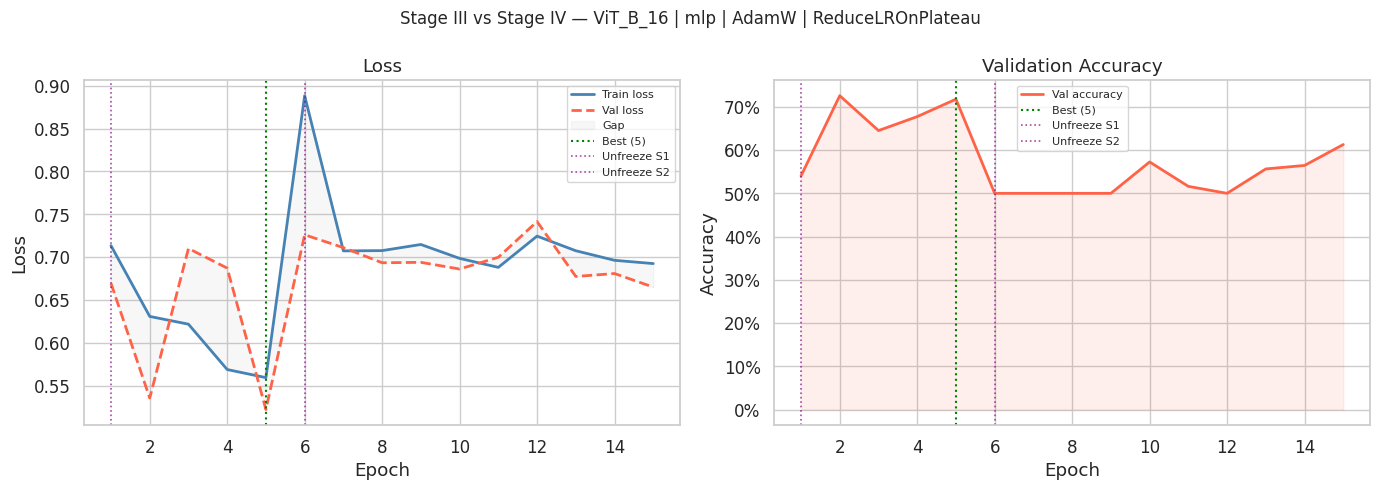

Best epoch: 5 | best val_loss: 0.5223


In [13]:
epochs_x = list(range(1, len(history["train_loss"]) + 1))
best_epoch = int(np.argmin(history["val_loss"])) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(epochs_x, history["train_loss"], label="Train loss", lw=2, color="steelblue")
ax.plot(epochs_x, history["val_loss"], label="Val loss", lw=2, color="tomato", ls="--")
ax.fill_between(epochs_x, history["train_loss"], history["val_loss"],
                alpha=0.06, color="grey", label="Gap")
ax.axvline(best_epoch, color="green", ls=":", lw=1.5, label=f"Best ({best_epoch})")
for ue, lab in [(UNFREEZE_EPOCH_STAGE1, "S1"), (UNFREEZE_EPOCH_STAGE2, "S2")]:
    if ue and ue <= len(epochs_x):
        ax.axvline(ue, color="purple", ls=":", lw=1.2, alpha=0.7, label=f"Unfreeze {lab}")
ax.set_title("Loss"); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(epochs_x, history["val_acc"], lw=2, color="tomato", label="Val accuracy")
ax.fill_between(epochs_x, history["val_acc"], alpha=0.1, color="tomato")
ax.axvline(best_epoch, color="green", ls=":", lw=1.5, label=f"Best ({best_epoch})")
for ue, lab in [(UNFREEZE_EPOCH_STAGE1, "S1"), (UNFREEZE_EPOCH_STAGE2, "S2")]:
    if ue and ue <= len(epochs_x):
        ax.axvline(ue, color="purple", ls=":", lw=1.2, alpha=0.7, label=f"Unfreeze {lab}")
ax.set_title("Validation Accuracy"); ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.legend(fontsize=8)

plt.suptitle(
    f"Stage III vs Stage IV — {MODEL_NAME} | {HEAD_TYPE} | {OPTIMIZER_NAME} | {SCHEDULER_NAME}",
    fontsize=12
)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Best epoch: {best_epoch} | best val_loss: {min(history['val_loss']):.4f}")

## 8. Evaluation - Confusion Matrix

Built 'ViT_B_16' | in_features=768 | head='mlp' | num_classes=2


Evaluating test set:   0%|          | 0/2 [00:00<?, ?it/s]

Exception in thread QueueFeederThread:
Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
    reader_close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 178, in close
    self._close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 377, in _close
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 291, in _feed
    queue_sem.release()
ValueError: semaphore or lock released too many times


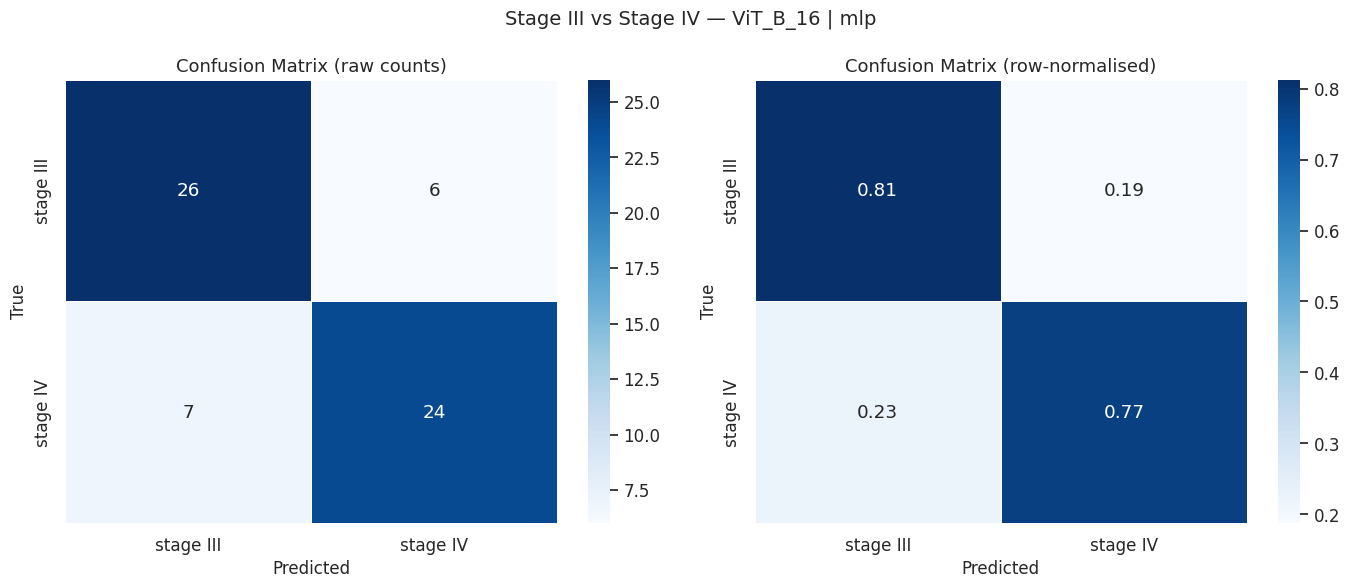

In [14]:
# Rebuild a clean model and load best weights
eval_model = build_model(
    MODEL_NAME, num_classes=NUM_CLASSES, dropout=DROPOUT,
    head_type=HEAD_TYPE, scale=SCALE, margin=MARGIN,
)
eval_model.load_state_dict(torch.load(BEST_WEIGHTS_PATH, map_location="cpu"))
eval_model.eval().to(device)

raw_test_loader = DataLoader(
    TransformedDataset(Subset(full_dataset, test_idx), val_test_transforms),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers,
)

all_labels_test, all_probs_test, all_preds_test = [], [], []
with torch.no_grad():
    for inputs, labels in tqdm(raw_test_loader, desc="Evaluating test set"):
        # No labels passed — inference mode
        logits = eval_model(inputs.to(device))
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()  # prob of class 1 (Stage IV)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_probs_test.extend(probs.tolist())
        all_preds_test.extend(preds.tolist())
        all_labels_test.extend(labels.numpy().tolist())

all_probs_test = np.array(all_probs_test)
all_preds_test = np.array(all_preds_test)
all_labels_test = np.array(all_labels_test)

cm_raw = confusion_matrix(all_labels_test, all_preds_test)
cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, cm, title, fmt in zip(
    axes,
    [cm_raw, cm_norm],
    ["Confusion Matrix (raw counts)", "Confusion Matrix (row-normalised)"],
    ["d", ".2f"]
):
    sns.heatmap(cm, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, ax=ax)
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("True", fontsize=12)
    ax.set_title(title, fontsize=13)
plt.suptitle(f"Stage III vs Stage IV — {MODEL_NAME} | {HEAD_TYPE}", fontsize=14)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Evaluation - Full Classification Report

In [15]:
print("=" * 55)
print("CLASSIFICATION REPORT - TEST SET")
print("=" * 55)
print(classification_report(all_labels_test, all_preds_test,
                             target_names=class_names, digits=4))

summary = {
    "Accuracy" : accuracy_score(all_labels_test, all_preds_test),
    "Macro Precision": precision_score(all_labels_test, all_preds_test, average="macro", zero_division=0),
    "Macro Recall": recall_score(all_labels_test, all_preds_test, average="macro", zero_division=0),
    "Macro F1": f1_score(all_labels_test, all_preds_test, average="macro", zero_division=0),
    "Weighted F1": f1_score(all_labels_test, all_preds_test, average="weighted", zero_division=0),
}
df = pd.DataFrame(summary.items(), columns=["Metric", "Value"])
df["Value"] = df["Value"].map("{:.4f}".format)
display(df.set_index("Metric"))
df.to_csv(f"{OUTPUT_DIR}/metrics_summary.csv", index=False)

CLASSIFICATION REPORT - TEST SET
              precision    recall  f1-score   support

   stage III     0.7879    0.8125    0.8000        32
    stage IV     0.8000    0.7742    0.7869        31

    accuracy                         0.7937        63
   macro avg     0.7939    0.7933    0.7934        63
weighted avg     0.7938    0.7937    0.7935        63



,Value
Metric,
Accuracy,0.7937
Macro Precision,0.7939
Macro Recall,0.7933
Macro F1,0.7934
Weighted F1,0.7935


## 10. Evaluation - ROC Curve & AUC with Youden Threshold 

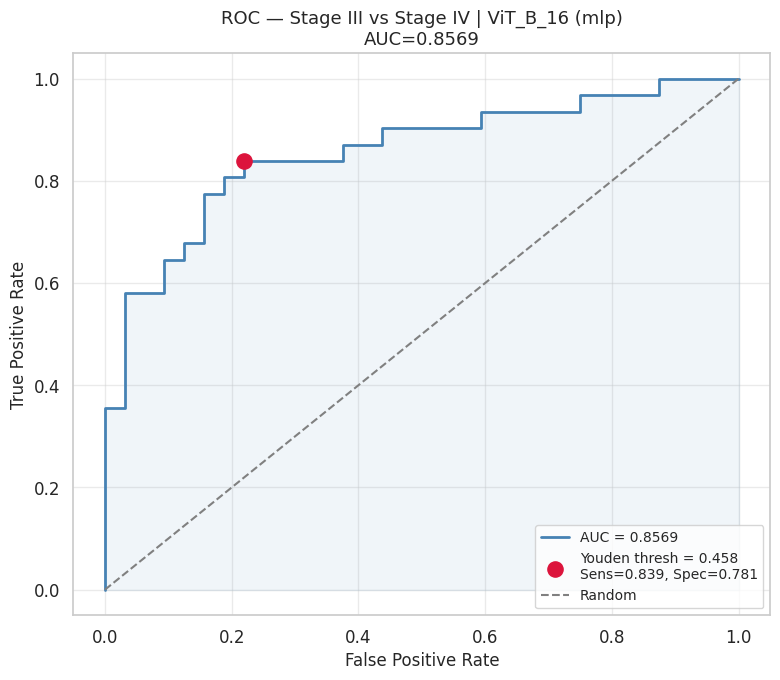

AUC-ROC : 0.8569
Youden threshold: 0.4577

At Youden threshold:
Accuracy : 0.8095
Macro F1 : 0.8095
Recall : 0.8387
Precision : 0.7879


In [16]:
# Positive class = Stage IV (higher / more severe)
pos_name = next(
    (c for c in class_names if "iv" in c.lower() or "4" in c),
    class_names[1]
)
pos_class_idx = full_dataset.class_to_idx[pos_name]
pos_probs = all_probs_test if pos_class_idx == 1 else (1 - all_probs_test)
binary_labels = (all_labels_test == pos_class_idx).astype(int)

fpr, tpr, thresholds = roc_curve(binary_labels, pos_probs)
auc_val = roc_auc_score(binary_labels, pos_probs)
youden_idx = int(np.argmax(tpr - fpr))
youden_thresh = float(thresholds[youden_idx])

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(fpr, tpr, lw=2, color="steelblue", label=f"AUC = {auc_val:.4f}")
ax.fill_between(fpr, tpr, alpha=0.08, color="steelblue")
ax.scatter(fpr[youden_idx], tpr[youden_idx], s=120, color="crimson", zorder=5,
           label=f"Youden thresh = {youden_thresh:.3f}\n"
                 f"Sens={tpr[youden_idx]:.3f}, Spec={1-fpr[youden_idx]:.3f}")
ax.plot([0, 1], [0, 1], "--", color="grey", lw=1.5, label="Random")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title(
    f"ROC — Stage III vs Stage IV | {MODEL_NAME} ({HEAD_TYPE})\nAUC={auc_val:.4f}",
    fontsize=13
)
ax.legend(fontsize=10, loc="lower right")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"AUC-ROC : {auc_val:.4f}")
print(f"Youden threshold: {youden_thresh:.4f}")
# Re-evaluate at Youden threshold using prob-based predictions
p_y = (pos_probs >= youden_thresh).astype(int)
print(f"\nAt Youden threshold:")
print(f"Accuracy : {accuracy_score(binary_labels, p_y):.4f}")
print(f"Macro F1 : {f1_score(binary_labels, p_y, average='macro'):.4f}")
print(f"Recall : {recall_score(binary_labels, p_y):.4f}")
print(f"Precision : {precision_score(binary_labels, p_y):.4f}")

## 11. Evaluation - Threshold Sensitivity Analysis

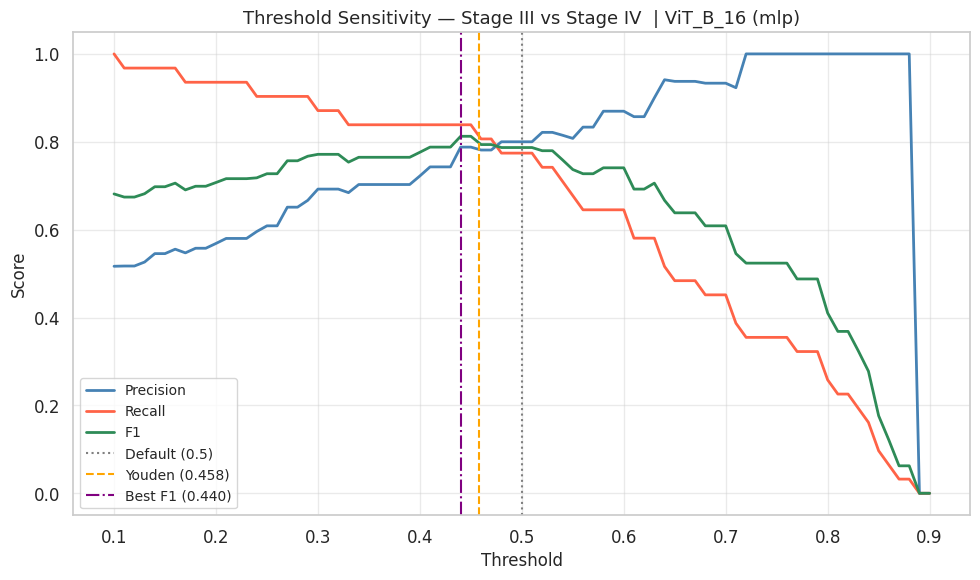

Best-F1 threshold: 0.44 F1=0.8125


In [17]:
thresh_range = np.linspace(0.1, 0.9, 81)
precisions, recalls, f1s = [], [], []
for t in thresh_range:
    pt = (pos_probs >= t).astype(int)
    precisions.append(precision_score(binary_labels, pt, zero_division=0))
    recalls.append(recall_score(binary_labels, pt, zero_division=0))
    f1s.append(f1_score(binary_labels, pt, zero_division=0))

best_f1_idx = int(np.argmax(f1s))
best_f1_thresh = float(thresh_range[best_f1_idx])

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresh_range, precisions, label="Precision", lw=2, color="steelblue")
ax.plot(thresh_range, recalls, label="Recall", lw=2, color="tomato")
ax.plot(thresh_range, f1s, label="F1", lw=2, color="seagreen")
ax.axvline(0.5, color="grey", ls=":", lw=1.5, label="Default (0.5)")
ax.axvline(youden_thresh, color="orange", ls="--", lw=1.5, label=f"Youden ({youden_thresh:.3f})")
ax.axvline(best_f1_thresh,color="purple", ls="-.", lw=1.5, label=f"Best F1 ({best_f1_thresh:.3f})")
ax.set_xlabel("Threshold", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title(
    f"Threshold Sensitivity — Stage III vs Stage IV  | {MODEL_NAME} ({HEAD_TYPE})",
    fontsize=13
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/threshold_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Best-F1 threshold: {best_f1_thresh:.2f} F1={f1s[best_f1_idx]:.4f}")

## 12. Model Export & Summary 

In [19]:
final_path = (
    f"{OUTPUT_DIR}/final_{MODEL_NAME}_{HEAD_TYPE}_{OPTIMIZER_NAME}_{SCHEDULER_NAME}.pth"
)
torch.save(accelerator.unwrap_model(model).state_dict(), final_path)

print("=" * 60)
print("TRAINING & EVALUATION SUMMARY — Stage III vs Stage IV")
print("=" * 60)
print(f"Model : {MODEL_NAME}")
print(f"Head  : {HEAD_TYPE}  |  Dropout: {DROPOUT}")
print(f"Margin head : {IS_MARGIN_HEAD}")
if IS_MARGIN_HEAD:
    # Resolve effective scale/margin (may have been auto-clamped)
    _h = accelerator.unwrap_model(model).head
    print(f"Effective scale : {_h.scale}  margin: {_h.margin}")
print(f"Loss : CrossEntropyLoss(label_smoothing={LABEL_SMOOTHING})")
print(f"Optimizer : {OPTIMIZER_NAME} | LR={LR:.2e} | WD={WEIGHT_DECAY:.2e}")
print(f"Scheduler : {SCHEDULER_NAME}")
print(f"Grad accumulation : {GRADIENT_ACCUMULATION}")
print(f"img_size : {IMG_SIZE}")
print(f"Epochs run : {len(history['train_loss'])} / {NUM_EPOCHS}")
print(f"Best epoch : {best_epoch} (val_loss={min(history['val_loss']):.4f})")
print(f"Early stop patience : {ES_PATIENCE}")
print()
print(f"Test set size : {len(all_labels_test)}")
print()
print(f"Accuracy : {accuracy_score(all_labels_test, all_preds_test):.4f}")
print(f"Macro F1 : {f1_score(all_labels_test, all_preds_test, average='macro'):.4f}")
print(f"Weighted F1 : {f1_score(all_labels_test, all_preds_test, average='weighted'):.4f}")
print(f"AUC-ROC : {auc_val:.4f}")
print(f"Youden threshold : {youden_thresh:.4f}")
print(f"Best-F1 threshold : {best_f1_thresh:.4f}")
print()
print("Saved artefacts:")
for fname in [
    "class_distribution.png", "training_curves.png",
    "confusion_matrices.png", "roc_curve.png",
    "threshold_sensitivity.png", "sample_predictions.png",
    "metrics_summary.csv",
    Path(BEST_WEIGHTS_PATH).name,
    Path(final_path).name,
]:
    p = Path(OUTPUT_DIR) / fname
    print(f"{'✅' if p.exists() else '❌'}  {fname}")

TRAINING & EVALUATION SUMMARY — Stage III vs Stage IV
Model : ViT_B_16
Head  : mlp  |  Dropout: 0.5444905836413285
Margin head : False
Loss : CrossEntropyLoss(label_smoothing=0.0)
Optimizer : AdamW | LR=1.13e-03 | WD=1.90e-05
Scheduler : ReduceLROnPlateau
Grad accumulation : 2
img_size : 224
Epochs run : 15 / 50
Best epoch : 5 (val_loss=0.5223)
Early stop patience : 10

Test set size : 63

Accuracy : 0.7937
Macro F1 : 0.7934
Weighted F1 : 0.7935
AUC-ROC : 0.8569
Youden threshold : 0.4577
Best-F1 threshold : 0.4400

Saved artefacts:
✅  class_distribution.png
✅  training_curves.png
✅  confusion_matrices.png
✅  roc_curve.png
✅  threshold_sensitivity.png
✅  sample_predictions.png
✅  metrics_summary.csv
✅  best_ViT_B_16_mlp_AdamW_ReduceLROnPlateau.pth
✅  final_ViT_B_16_mlp_AdamW_ReduceLROnPlateau.pth
